# Neuromorphic Obstacle Prediction — Data Preprocessing & SNN Training

## 1. Imports

In [185]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import snntorch as snn
from snntorch import surrogate

from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib

## 2. Data Loading & Cleaning

Steps:
- Drop the CSV index artifact column (`Unnamed: 0`).
- Keep only **valid** readings (`valid == 1`).
- Remove rows recorded **before the baseline was learned** (`baseline_cm > 0`).
- Clamp filtered distance to the physically plausible range **20 – 600 cm**.

In [186]:
df = pd.read_csv("sensor.csv")
df = df.drop(columns=["Unnamed: 0"], errors="ignore")
print("Original shape:", df.shape)

# Keep only valid readings
df = df[df["valid"] == 1].copy()

# Remove rows before baseline is learned
df = df[df["baseline_cm"] > 0].copy()

# Remove impossible distances
df = df[(df["dist_f_cm"] > 20) & (df["dist_f_cm"] <= 600)].copy()

print("After cleaning:", df.shape)
print(df.head())

Original shape: (26273, 13)
After cleaning: (22270, 13)
    session_id scenario  time_ms  sensor_id  echo_us  valid  dist_cm  \
37           1     safe    31513          1     3646      1    269.8   
38           1     safe    31795          1     3629      1    268.5   
39           1     safe    32078          1     3657      1    270.6   
40           1     safe    32347          1     3659      1    270.8   
41           1     safe    32617          1     3627      1    268.4   

    dist_f_cm  baseline_cm  enter_thr_cm  exit_thr_cm  danger  event  
37      267.5        268.3         120.0        140.0     0.0      0  
38      267.8        268.3         208.3        228.3     0.0      0  
39      268.5        268.3         208.3        228.3     0.0      0  
40      269.1        268.3         208.3        228.3     0.0      0  
41      268.9        268.3         208.3        228.3     0.0      0  


## 3. Feature Engineering

In [187]:
# Group column for session-aware computations
group_cols = []
if "session_id" in df.columns:
    group_cols.append("session_id")

# Distance deviation from baseline
df["delta"] = df["dist_f_cm"] - df["baseline_cm"]

# Distance to thresholds
df["dist_to_enter"] = df["dist_f_cm"] - df["enter_thr_cm"]
df["dist_to_exit"]  = df["dist_f_cm"] - df["exit_thr_cm"]

# Time gap (per session) — with fallback when no session column exists
if group_cols:
    df["time_gap"] = df.groupby(group_cols)["time_ms"].diff()
else:
    df["time_gap"] = df["time_ms"].diff()
df = df.dropna(subset=["time_gap"])

# Guard against zero time_gap (duplicate timestamps) to avoid inf/NaN
df["time_gap"] = df["time_gap"].replace(0, np.nan)
df = df.dropna(subset=["time_gap"])

# Velocity & acceleration
if group_cols:
    df["velocity"]     = df.groupby(group_cols)["dist_f_cm"].diff() / df["time_gap"]
    df["acceleration"] = df.groupby(group_cols)["velocity"].diff()  / df["time_gap"]
else:
    df["velocity"]     = df["dist_f_cm"].diff() / df["time_gap"]
    df["acceleration"] = df["velocity"].diff()  / df["time_gap"]
df = df.dropna(subset=["velocity", "acceleration"])

print("After feature engineering:", df.shape)
print(df.head())

After feature engineering: (22009, 19)
    session_id scenario  time_ms  sensor_id  echo_us  valid  dist_cm  \
40           1     safe    32347          1     3659      1    270.8   
41           1     safe    32617          1     3627      1    268.4   
42           1     safe    32905          1     3656      1    270.5   
43           1     safe    33191          1     3667      1    271.4   
44           1     safe    33474          1     3679      1    272.2   

    dist_f_cm  baseline_cm  enter_thr_cm  exit_thr_cm  danger  event  delta  \
40      269.1        268.3         208.3        228.3     0.0      0    0.8   
41      268.9        268.3         208.3        228.3     0.0      0    0.6   
42      269.3        268.3         208.3        228.3     0.0      0    1.0   
43      269.8        268.3         208.3        228.3     0.0      0    1.5   
44      270.4        268.3         208.3        228.3     0.0      0    2.1   

    dist_to_enter  dist_to_exit  time_gap  velocity  

## 4. Feature & Label Selection

In [188]:
feature_cols = ["time_gap", "dist_f_cm", "delta", "velocity", "acceleration"]

if "state" not in df.columns:
    df["state"] = (df["danger"] > 0).astype(int)
label_col = "state"  

print("Features:", feature_cols)
print("Label:   ", label_col)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:  ", device)

Features: ['time_gap', 'dist_f_cm', 'delta', 'velocity', 'acceleration']
Label:    state
Device:   cpu


## 5. Send-on-Delta Encoder

Converts a continuous-valued window `(batch, time_steps, features)` into binary
ON / OFF spikes `(batch, time_steps, features × 2)`.  A spike is emitted
whenever the change from the last reference exceeds a threshold.

In [189]:
def delta_encoder(x, threshold):
    # Send-on-Delta modulation: continuous -> ON/OFF spikes.
    batch_size, time_steps, features = x.shape
    spikes = torch.zeros((batch_size, time_steps, features * 2), device=x.device)
    reference = x[:, 0, :]

    for t in range(1, time_steps):
        current_val = x[:, t, :]
        diff = current_val - reference
        on_spikes  = (diff >=  threshold).float()
        off_spikes = (diff <= -threshold).float()
        spike_mask = torch.logical_or(on_spikes > 0, off_spikes > 0).float()
        reference  = reference * (1 - spike_mask) + current_val * spike_mask
        spikes[:, t, :features] = on_spikes
        spikes[:, t, features:] = off_spikes

    return spikes

## 6. Event-Driven SNN Architecture

In [190]:
class EventDrivenSNN(nn.Module):
    def __init__(self, input_size=5, hidden_size=32, output_size=2,
                 beta=0.9, encode_threshold=0.5):
        super().__init__()
        self.encode_threshold = encode_threshold
        self.fc1 = nn.Linear(input_size * 2, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, output_size)
        spike_grad = surrogate.fast_sigmoid()
        self.lif1 = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.lif3 = snn.Leaky(beta=beta, spike_grad=spike_grad)

    def forward(self, x):
        spk_in = delta_encoder(x, self.encode_threshold)
        time_steps = spk_in.size(1)
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()
        mem3_rec = []
        for t in range(time_steps):
            cur1 = self.fc1(spk_in[:, t, :])
            spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            cur3 = self.fc3(spk2)
            spk3, mem3 = self.lif3(cur3, mem3)
            mem3_rec.append(mem3)
        return torch.stack(mem3_rec, dim=0)  # (time_steps, batch, output_size)

## 7. Helper Functions

In [191]:
#Window builder
def build_windows(df, feature_cols, label_col, group_cols,
                  window_size, step_size, pred_horizon):
    X, y, sids = [], [], []
    for group_key, group in df.groupby(group_cols):
        group = group.sort_values("time_ms").reset_index(drop=True)
        if len(group) < window_size + pred_horizon:
            continue
        sid = group_key if not isinstance(group_key, tuple) else group_key[0]
        for start in range(0, len(group) - window_size - pred_horizon + 1, step_size):
            end = start + window_size
            label_idx = end - 1 + pred_horizon
            X.append(group.iloc[start:end][feature_cols].values)
            y.append(group.iloc[label_idx][label_col])
            sids.append(sid)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64), np.array(sids)


#Session-based split
def session_based_split(X, y, session_ids,
                        train_ratio=0.70, val_ratio=0.15, seed=42):
    unique = np.unique(session_ids)
    rng = np.random.RandomState(seed)
    rng.shuffle(unique)
    n = len(unique)

    # Ensure at least 1 session in val and test
    train_end = max(1, int(train_ratio * n))
    val_end   = max(train_end + 1, int((train_ratio + val_ratio) * n))
    if val_end >= n:
        val_end = n - 1        
    if train_end >= val_end:
        train_end = val_end - 1  

    train_s = set(unique[:train_end])
    val_s   = set(unique[train_end:val_end])
    test_s  = set(unique[val_end:])

    train_mask = np.isin(session_ids, list(train_s))
    val_mask   = np.isin(session_ids, list(val_s))
    test_mask  = np.isin(session_ids, list(test_s))

    return (X[train_mask], y[train_mask],
            X[val_mask],   y[val_mask],
            X[test_mask],  y[test_mask],
            train_s, val_s, test_s)


#Training loop
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        output = model(xb)[-1]     
        loss = criterion(output, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
        all_preds.extend(torch.argmax(output, 1).cpu().numpy())
        all_labels.extend(yb.cpu().numpy())
    return running_loss / len(loader.dataset), accuracy_score(all_labels, all_preds)


#Evaluation loop
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            output = model(xb)[-1]
            loss = criterion(output, yb)
            running_loss += loss.item() * xb.size(0)
            all_preds.extend(torch.argmax(output, 1).cpu().numpy())
            all_labels.extend(yb.cpu().numpy())
    return running_loss / len(loader.dataset), accuracy_score(all_labels, all_preds), all_labels, all_preds

## 8. Full Training Pipeline

In [192]:
WINDOW_SIZE = 15
STEP_SIZE   = 5
NUM_EPOCHS  = 20
BATCH_SIZE  = 64

def run_pipeline(pred_horizon):
    print(f"\n{'=' * 60}")
    print(f"  PRED_HORIZON = {pred_horizon}")
    print(f"{'=' * 60}\n")

    #Build windows
    X, y, sids = build_windows(df, feature_cols, label_col, group_cols,
                               WINDOW_SIZE, STEP_SIZE, pred_horizon)
    print(f"Windows: {X.shape[0]}  |  Shape: {X.shape}")
    uniq, cnts = np.unique(y, return_counts=True)
    print(f"Labels:  {dict(zip(uniq, cnts))}")

    #Session-based split
    (X_tr, y_tr, X_va, y_va, X_te, y_te,
     tr_s, va_s, te_s) = session_based_split(X, y, sids)
    print(f"\nTrain sessions: {sorted(tr_s)}  ({X_tr.shape[0]} windows)")
    print(f"Val   sessions: {sorted(va_s)}  ({X_va.shape[0]} windows)")
    print(f"Test  sessions: {sorted(te_s)}  ({X_te.shape[0]} windows)")
    assert not (tr_s & va_s) and not (tr_s & te_s) and not (va_s & te_s), \
        "Session overlap!"

    #Normalise (fit on train only)
    n_tr, t_dim, f_dim = X_tr.shape
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr.reshape(-1, f_dim)).reshape(n_tr, t_dim, f_dim)
    X_va_s = scaler.transform(X_va.reshape(-1, f_dim)).reshape(X_va.shape)
    X_te_s = scaler.transform(X_te.reshape(-1, f_dim)).reshape(X_te.shape)

    #DataLoaders
    mk = lambda x, y, shuf: DataLoader(
        TensorDataset(torch.tensor(x, dtype=torch.float32),
                      torch.tensor(y, dtype=torch.long)),
        batch_size=BATCH_SIZE, shuffle=shuf)
    train_dl = mk(X_tr_s, y_tr, True)
    val_dl   = mk(X_va_s, y_va, False)
    test_dl  = mk(X_te_s, y_te, False)

    #Class weights
    cw = compute_class_weight("balanced",
                              classes=np.unique(y_tr), y=y_tr)
    cw_t = torch.tensor(cw, dtype=torch.float32).to(device)
    print(f"Class weights: {cw_t}")
    criterion = nn.CrossEntropyLoss(weight=cw_t)

    #Model & optimiser
    model = EventDrivenSNN(input_size=len(feature_cols),
                           hidden_size=32, output_size=2, beta=0.9).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)

    #Training loop
    hist = {"tl": [], "vl": [], "ta": [], "va": []}
    for ep in range(1, NUM_EPOCHS + 1):
        tl, ta = train_one_epoch(model, train_dl, opt, criterion)
        vl, va, _, _ = evaluate(model, val_dl, criterion)
        hist["tl"].append(tl); hist["vl"].append(vl)
        hist["ta"].append(ta); hist["va"].append(va)
        print(f"Epoch [{ep:>2}/{NUM_EPOCHS}] "
              f"TrLoss {tl:.4f} | TrAcc {ta:.4f} | "
              f"VaLoss {vl:.4f} | VaAcc {va:.4f}")

    #Test evaluation
    te_loss, te_acc, y_true, y_pred = evaluate(model, test_dl, criterion)
    print(f"\nTest Loss: {te_loss:.4f}  |  Test Acc: {te_acc:.4f}")
    print(classification_report(y_true, y_pred,
                                target_names=["Safe", "Danger"]))
    cm = confusion_matrix(y_true, y_pred)

    #Plots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].plot(hist["tl"], label="Train"); axes[0].plot(hist["vl"], label="Val")
    axes[0].legend(); axes[0].set_title(f"Loss  (horizon={pred_horizon})")
    axes[1].plot(hist["ta"], label="Train"); axes[1].plot(hist["va"], label="Val")
    axes[1].legend(); axes[1].set_title(f"Accuracy  (horizon={pred_horizon})")
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Safe","Danger"],
                yticklabels=["Safe","Danger"], ax=axes[2])
    axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("Actual")
    axes[2].set_title(f"Confusion Matrix  (horizon={pred_horizon})")
    plt.tight_layout(); plt.show()

    return dict(pred_horizon=pred_horizon, test_acc=te_acc, test_loss=te_loss,
                y_true=y_true, y_pred=y_pred, model=model, scaler=scaler)

## 9. Run Experiments


  PRED_HORIZON = 0

Windows: 4191  |  Shape: (4191, 15, 5)
Labels:  {np.int64(0): np.int64(3423), np.int64(1): np.int64(768)}

Train sessions: [np.int64(1), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(23), np.int64(25), np.int64(26), np.int64(28), np.int64(30), np.int64(32), np.int64(33), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(40), np.int64(41), np.int64(42), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(51), np.int64(52), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(64), np.int64(67), np.int64(68), np.int64(69), np.int64(70), np.int64(71), np.int64(72), np.int64(76), np.int64(77), np.int64(80), np.int64(82), np.int64(83), np.int64(84), np.int64(87), np.int64(88), np.int64(89), np.int64(90)]  (2833 windows)
Val   

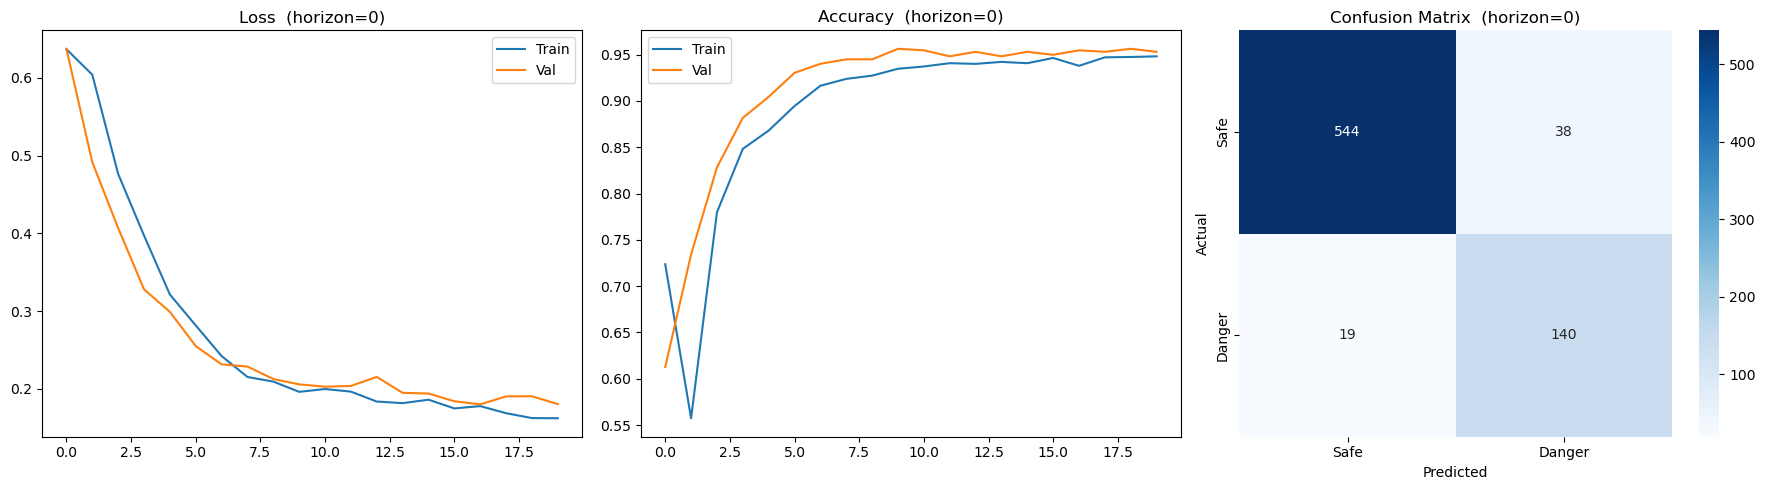


  PRED_HORIZON = 5

Windows: 4104  |  Shape: (4104, 15, 5)
Labels:  {np.int64(0): np.int64(3336), np.int64(1): np.int64(768)}

Train sessions: [np.int64(1), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(23), np.int64(25), np.int64(26), np.int64(28), np.int64(30), np.int64(32), np.int64(33), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(40), np.int64(41), np.int64(42), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(51), np.int64(52), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(64), np.int64(67), np.int64(68), np.int64(69), np.int64(70), np.int64(71), np.int64(72), np.int64(76), np.int64(77), np.int64(80), np.int64(82), np.int64(83), np.int64(84), np.int64(87), np.int64(88), np.int64(89), np.int64(90)]  (2773 windows)
Val   

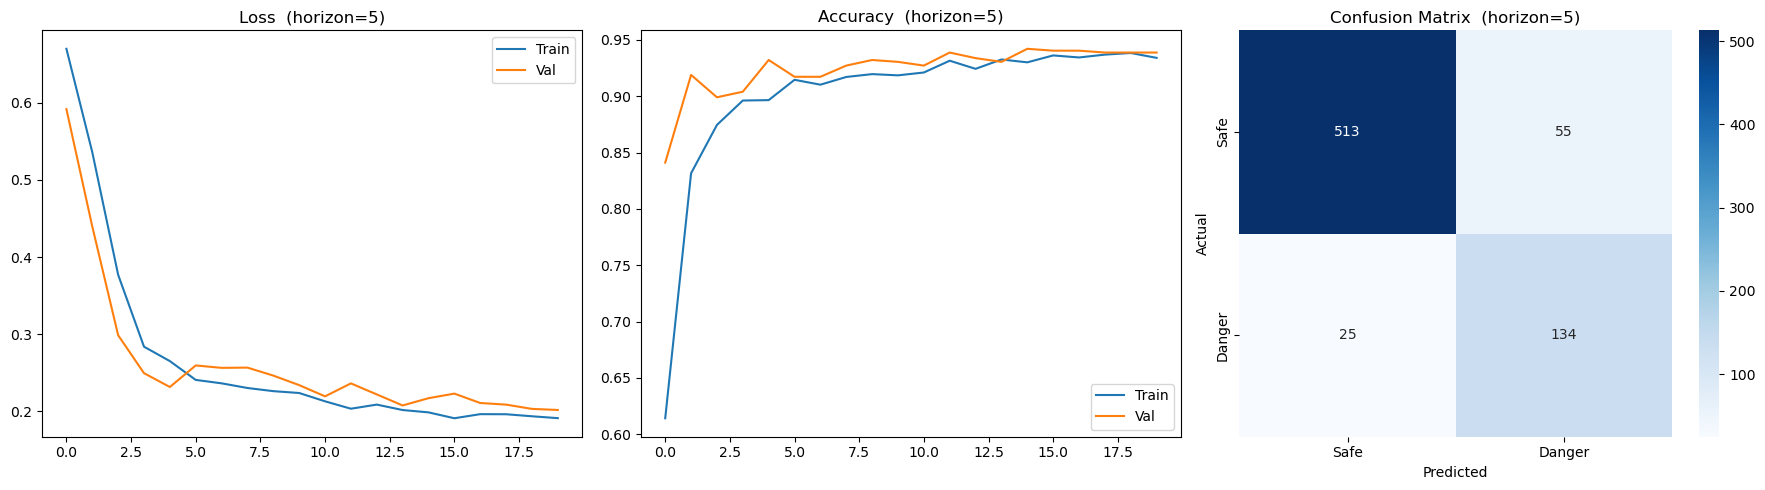

In [193]:
results = {}
for ph in [0,5]:
    results[ph] = run_pipeline(ph)

## 10. Results Comparison

In [194]:
print(f"\n{'=' * 60}")
print(f"  PRED_HORIZON COMPARISON")
print(f"{'=' * 60}")
print(f"\n{'Metric':<25} {'HORIZON=0':>12} {'HORIZON=5':>12}")
print("-" * 50)
print(f"{'Test Accuracy':<25} {results[0]['test_acc']:>12.4f} {results[5]['test_acc']:>12.4f}")
print(f"{'Test Loss':<25} {results[0]['test_loss']:>12.4f} {results[5]['test_loss']:>12.4f}")

for ph in [0, 5]:
    rpt = classification_report(results[ph]["y_true"], results[ph]["y_pred"],
                                target_names=["Safe", "Danger"], output_dict=True)
    print(f"\nPRED_HORIZON = {ph}:")
    print(f"  Safe   — P: {rpt['Safe']['precision']:.4f}  "
          f"R: {rpt['Safe']['recall']:.4f}  F1: {rpt['Safe']['f1-score']:.4f}")
    print(f"  Danger — P: {rpt['Danger']['precision']:.4f}  "
          f"R: {rpt['Danger']['recall']:.4f}  F1: {rpt['Danger']['f1-score']:.4f}")


  PRED_HORIZON COMPARISON

Metric                       HORIZON=0    HORIZON=5
--------------------------------------------------
Test Accuracy                   0.9231       0.8900
Test Loss                       0.1950       0.2791

PRED_HORIZON = 0:
  Safe   — P: 0.9663  R: 0.9347  F1: 0.9502
  Danger — P: 0.7865  R: 0.8805  F1: 0.8309

PRED_HORIZON = 5:
  Safe   — P: 0.9535  R: 0.9032  F1: 0.9277
  Danger — P: 0.7090  R: 0.8428  F1: 0.7701


## 11. Save Model & Scaler

In [195]:
best_ph = max(results, key=lambda k: results[k]["test_acc"])
print(f"Best horizon: {best_ph}  (Test Acc: {results[best_ph]['test_acc']:.4f})")

checkpoint = {
    "model_class":      "EventDrivenSNN",
    "model_state_dict": results[best_ph]["model"].state_dict(),
    "feature_cols":     feature_cols,
    "window_size":      WINDOW_SIZE,
    "step_size":        STEP_SIZE,
    "pred_horizon":     best_ph,
    "input_size":       len(feature_cols),
    "hidden_size":      32,
    "output_size":      2,
    "beta":             0.9,
    "encode_threshold": 0.5,
    "test_accuracy":    results[best_ph]["test_acc"],
}
torch.save(checkpoint, "snn_obstacle_model.pth")
joblib.dump(results[best_ph]["scaler"], "feature_scaler.pkl")
print("Saved: snn_obstacle_model.pth, feature_scaler.pkl")

Best horizon: 0  (Test Acc: 0.9231)
Saved: snn_obstacle_model.pth, feature_scaler.pkl


---
## 12. Baseline Comparison — RF · LSTM · GRU · 1D-CNN · MLP · SNN

### Rebuild Exact Split & Scaler

Recover the trained SNN and reconstruct the identical train/val/test split using the same `build_windows` + `session_based_split` + saved scaler from `run_pipeline`.  **No data leakage** — scaler was fit on train only.


In [196]:
import time, warnings
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
warnings.filterwarnings("ignore")

# ── Which horizon to evaluate ─────────────────────────────────────────
# Match whichever horizon was saved as best_ph in Cell 22.
# Cell 22 saves:  best_ph = max(results, key=lambda k: results[k]["test_acc"])
# If HORIZON=0 had higher accuracy (reactive detection is easier),
# best_ph=0 was saved.  We always evaluate on the SAME horizon the
# checkpoint used — otherwise we compare different tasks.
ph = max(results, key=lambda k: results[k]["test_acc"])
print(f"Best saved horizon: {ph}  (matching checkpoint)")

# ── Recover trained SNN and its scaler ───────────────────────────────
SNN_MODEL   = results[ph]["model"]
SNN_MODEL.eval()
saved_scaler = results[ph]["scaler"]

# ── Rebuild windows (identical to run_pipeline internals) ─────────────
X_all, y_all, sids_all = build_windows(
    df, feature_cols, label_col, group_cols,
    WINDOW_SIZE, STEP_SIZE, pred_horizon=ph)

# ── Rebuild the exact same session split (same seed=42) ───────────────
(X_tr, y_tr, X_va, y_va, X_te, y_te,
 tr_s, va_s, te_s) = session_based_split(X_all, y_all, sids_all)

# ── Apply the saved scaler (already fit on train) ─────────────────────
n_tr, t_dim, f_dim = X_tr.shape
X_tr_s = saved_scaler.transform(X_tr.reshape(-1, f_dim)).reshape(n_tr,  t_dim, f_dim)
X_va_s = saved_scaler.transform(X_va.reshape(-1, f_dim)).reshape(X_va.shape)
X_te_s = saved_scaler.transform(X_te.reshape(-1, f_dim)).reshape(X_te.shape)

# Overwrite for downstream cells (all baselines use X_tr_s / X_te_s)
X_tr, X_va, X_te = X_tr_s, X_va_s, X_te_s

# ── Class-weighted loss (shared by all neural models) ─────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SNN_MODEL = SNN_MODEL.to(device)

cw   = compute_class_weight("balanced", classes=np.unique(y_tr), y=y_tr)
cw_t = torch.tensor(cw, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=cw_t)
NUM_EPOCHS = 20

# ── Shared DataLoaders ────────────────────────────────────────────────
tr_ld = DataLoader(
    TensorDataset(torch.tensor(X_tr, dtype=torch.float32),
                  torch.tensor(y_tr, dtype=torch.long)),
    batch_size=64, shuffle=True)
te_ld = DataLoader(
    TensorDataset(torch.tensor(X_te, dtype=torch.float32),
                  torch.tensor(y_te, dtype=torch.long)),
    batch_size=64, shuffle=False)

print(f"Rebuilt split — HORIZON={ph}")
print(f"  Train : {len(X_tr):,} windows  "
      f"(Safe={int((y_tr==0).sum())} Danger={int((y_tr==1).sum())})")
print(f"  Val   : {len(X_va):,} windows")
print(f"  Test  : {len(X_te):,} windows  "
      f"(Safe={int((y_te==0).sum())} Danger={int((y_te==1).sum())})")
print(f"  Class weights  →  Safe={cw[0]:.3f}  Danger={cw[1]:.3f}")


Best saved horizon: 0  (matching checkpoint)
Rebuilt split — HORIZON=0
  Train : 2,833 windows  (Safe=2337 Danger=496)
  Val   : 617 windows
  Test  : 741 windows  (Safe=582 Danger=159)
  Class weights  →  Safe=0.606  Danger=2.856


###Random Forest Baseline


Random Forest  HORIZON=0
  Nodes (≈params) : 5,204
  Accuracy        : 99.46%
  Safe   P/R/F1   : 0.9966 / 0.9966 / 0.9966
  Danger P/R/F1   : 0.9874 / 0.9874 / 0.9874
  Inference       : 0.0524 ms/window
  Train time      : 0.30 s

              precision    recall  f1-score   support

        Safe     0.9966    0.9966    0.9966       582
      Danger     0.9874    0.9874    0.9874       159

    accuracy                         0.9946       741
   macro avg     0.9920    0.9920    0.9920       741
weighted avg     0.9946    0.9946    0.9946       741



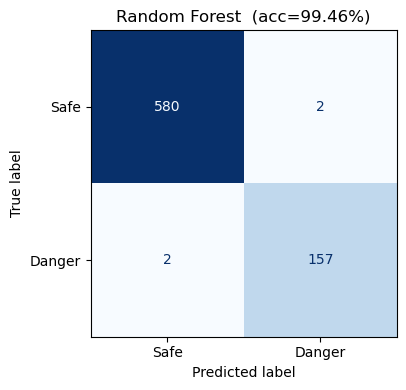

In [197]:
# Flatten (N, 15, 5) → (N, 75)
X_tr_rf = X_tr.reshape(len(X_tr), -1)
X_te_rf = X_te.reshape(len(X_te), -1)

t0 = time.time()
rf = RandomForestClassifier(
    n_estimators=100, max_depth=10,
    class_weight="balanced",
    random_state=42, n_jobs=-1)
rf.fit(X_tr_rf, y_tr)
RF_TRAIN_T = time.time() - t0

rf.predict(X_te_rf[:5])              
t0 = time.time()
rf_pred   = rf.predict(X_te_rf)
RF_INF_MS = (time.time() - t0) / len(y_te) * 1000

RF_ACC   = accuracy_score(y_te, rf_pred)
RF_CM    = confusion_matrix(y_te, rf_pred)
RF_REP   = classification_report(y_te, rf_pred,
               target_names=["Safe","Danger"], digits=4, output_dict=True)
RF_NODES = sum(t.tree_.node_count for t in rf.estimators_)

print(f"Random Forest  HORIZON={ph}")
print(f"  Nodes (≈params) : {RF_NODES:,}")
print(f"  Accuracy        : {RF_ACC*100:.2f}%")
print(f"  Safe   P/R/F1   : "
      f"{RF_REP['Safe']['precision']:.4f} / "
      f"{RF_REP['Safe']['recall']:.4f} / "
      f"{RF_REP['Safe']['f1-score']:.4f}")
print(f"  Danger P/R/F1   : "
      f"{RF_REP['Danger']['precision']:.4f} / "
      f"{RF_REP['Danger']['recall']:.4f} / "
      f"{RF_REP['Danger']['f1-score']:.4f}")
print(f"  Inference       : {RF_INF_MS:.4f} ms/window")
print(f"  Train time      : {RF_TRAIN_T:.2f} s")
print()
print(classification_report(y_te, rf_pred, target_names=["Safe","Danger"], digits=4))

fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(RF_CM, display_labels=["Safe","Danger"]).plot(
    ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Random Forest  (acc={RF_ACC*100:.2f}%)")
plt.tight_layout(); plt.show()


### 12.3  LSTM Baseline

Two-layer LSTM over 15 timesteps.  Dense: processes every timestep with full float32 matrix multiplications regardless of whether the reading changed.  
Primary recurrent comparison — most commonly used architecture in the AUV obstacle-detection literature.


LSTM  parameters: 13,506
  Epoch  5/20  loss=0.0487
  Epoch 10/20  loss=0.0294
  Epoch 15/20  loss=0.0240
  Epoch 20/20  loss=0.0180

LSTM  HORIZON=0
  Accuracy      : 98.65%
  Danger Recall : 1.0000
  Inference     : 0.1725 ms/window
  Train time    : 5.8 s

              precision    recall  f1-score   support

        Safe     1.0000    0.9828    0.9913       582
      Danger     0.9408    1.0000    0.9695       159

    accuracy                         0.9865       741
   macro avg     0.9704    0.9914    0.9804       741
weighted avg     0.9873    0.9865    0.9867       741



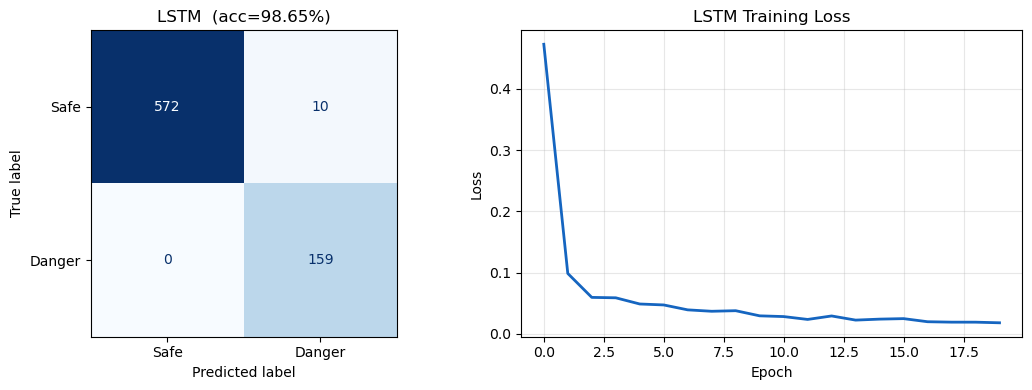

In [198]:
class LSTMBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(5, 32, num_layers=2, batch_first=True, dropout=0.2)
        self.fc   = nn.Linear(32, 2)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

lstm_model = LSTMBaseline().to(device)
LSTM_PARAMS = sum(p.numel() for p in lstm_model.parameters())
print(f"LSTM  parameters: {LSTM_PARAMS:,}")

opt = torch.optim.Adam(lstm_model.parameters(), lr=1e-3, weight_decay=1e-4)
sch = torch.optim.lr_scheduler.StepLR(opt, step_size=8, gamma=0.5)

t0 = time.time()
lstm_losses = []
for ep in range(NUM_EPOCHS):
    lstm_model.train(); ep_loss = 0
    for Xb, yb in tr_ld:
        Xb, yb = Xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = criterion(lstm_model(Xb), yb)
        loss.backward(); opt.step()
        ep_loss += loss.item()
    sch.step()
    lstm_losses.append(ep_loss / len(tr_ld))
    if (ep+1) % 5 == 0:
        print(f"  Epoch {ep+1:>2}/{NUM_EPOCHS}  loss={lstm_losses[-1]:.4f}")
LSTM_TRAIN_T = time.time() - t0

lstm_model.eval()
yp_l, yt_l, lstm_times = [], [], []
with torch.no_grad():
    for Xb, yb in te_ld:
        t0 = time.time()
        out = lstm_model(Xb.to(device))
        lstm_times.append((time.time()-t0) * 1000 / len(Xb))
        yp_l.extend(out.argmax(1).cpu().numpy())
        yt_l.extend(yb.numpy())

LSTM_INF_MS = float(np.mean(lstm_times))
LSTM_ACC  = accuracy_score(yt_l, yp_l)
LSTM_CM   = confusion_matrix(yt_l, yp_l)
LSTM_REP  = classification_report(yt_l, yp_l,
                target_names=["Safe","Danger"], digits=4, output_dict=True)

print(f"\nLSTM  HORIZON={ph}")
print(f"  Accuracy      : {LSTM_ACC*100:.2f}%")
print(f"  Danger Recall : {LSTM_REP['Danger']['recall']:.4f}")
print(f"  Inference     : {LSTM_INF_MS:.4f} ms/window")
print(f"  Train time    : {LSTM_TRAIN_T:.1f} s")
print()
print(classification_report(yt_l, yp_l, target_names=["Safe","Danger"], digits=4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay(LSTM_CM, display_labels=["Safe","Danger"]).plot(
    ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title(f"LSTM  (acc={LSTM_ACC*100:.2f}%)")
axes[1].plot(lstm_losses, color="#1565C0", lw=2)
axes[1].set(xlabel="Epoch", ylabel="Loss", title="LSTM Training Loss")
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


### GRU Baseline


GRU   parameters: 10,146  (25% lighter than LSTM)
  Epoch  5/20  loss=0.0342
  Epoch 10/20  loss=0.0243
  Epoch 15/20  loss=0.0250
  Epoch 20/20  loss=0.0193

GRU  HORIZON=0
  Accuracy      : 99.33%
  Danger Recall : 1.0000
  Inference     : 0.0473 ms/window
  Train time    : 14.3 s

              precision    recall  f1-score   support

        Safe     1.0000    0.9914    0.9957       582
      Danger     0.9695    1.0000    0.9845       159

    accuracy                         0.9933       741
   macro avg     0.9848    0.9957    0.9901       741
weighted avg     0.9935    0.9933    0.9933       741



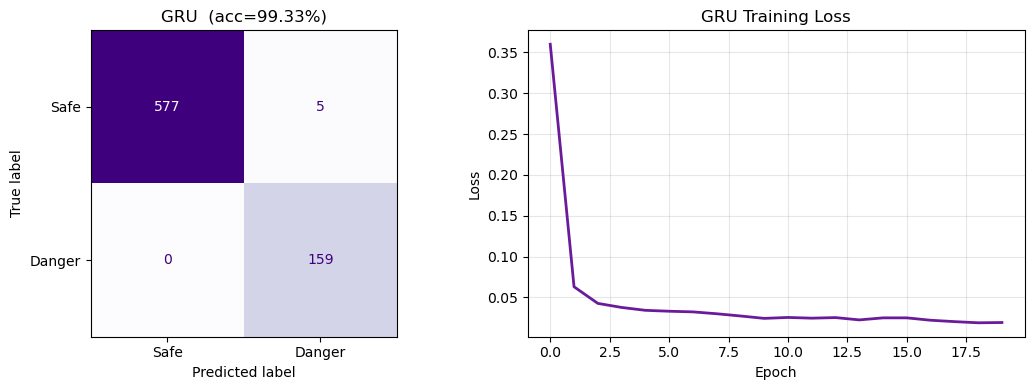

In [199]:
class GRUBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(5, 32, num_layers=2, batch_first=True, dropout=0.2)
        self.fc  = nn.Linear(32, 2)
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

gru_model = GRUBaseline().to(device)
GRU_PARAMS = sum(p.numel() for p in gru_model.parameters())
print(f"GRU   parameters: {GRU_PARAMS:,}  "
      f"({(LSTM_PARAMS-GRU_PARAMS)/LSTM_PARAMS*100:.0f}% lighter than LSTM)")

opt = torch.optim.Adam(gru_model.parameters(), lr=1e-3, weight_decay=1e-4)
sch = torch.optim.lr_scheduler.StepLR(opt, step_size=8, gamma=0.5)

t0 = time.time()
gru_losses = []
for ep in range(NUM_EPOCHS):
    gru_model.train(); ep_loss = 0
    for Xb, yb in tr_ld:
        Xb, yb = Xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = criterion(gru_model(Xb), yb)
        loss.backward(); opt.step()
        ep_loss += loss.item()
    sch.step()
    gru_losses.append(ep_loss / len(tr_ld))
    if (ep+1) % 5 == 0:
        print(f"  Epoch {ep+1:>2}/{NUM_EPOCHS}  loss={gru_losses[-1]:.4f}")
GRU_TRAIN_T = time.time() - t0

gru_model.eval()
yp_g, yt_g, gru_times = [], [], []
with torch.no_grad():
    for Xb, yb in te_ld:
        t0 = time.time()
        out = gru_model(Xb.to(device))
        gru_times.append((time.time()-t0) * 1000 / len(Xb))
        yp_g.extend(out.argmax(1).cpu().numpy())
        yt_g.extend(yb.numpy())

GRU_INF_MS = float(np.mean(gru_times))
GRU_ACC  = accuracy_score(yt_g, yp_g)
GRU_CM   = confusion_matrix(yt_g, yp_g)
GRU_REP  = classification_report(yt_g, yp_g,
               target_names=["Safe","Danger"], digits=4, output_dict=True)

print(f"\nGRU  HORIZON={ph}")
print(f"  Accuracy      : {GRU_ACC*100:.2f}%")
print(f"  Danger Recall : {GRU_REP['Danger']['recall']:.4f}")
print(f"  Inference     : {GRU_INF_MS:.4f} ms/window")
print(f"  Train time    : {GRU_TRAIN_T:.1f} s")
print()
print(classification_report(yt_g, yp_g, target_names=["Safe","Danger"], digits=4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay(GRU_CM, display_labels=["Safe","Danger"]).plot(
    ax=axes[0], colorbar=False, cmap="Purples")
axes[0].set_title(f"GRU  (acc={GRU_ACC*100:.2f}%)")
axes[1].plot(gru_losses, color="#6A1B9A", lw=2)
axes[1].set(xlabel="Epoch", ylabel="Loss", title="GRU Training Loss")
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


### 1D-CNN Baseline (Temporal Convolutional Network)


1D-CNN parameters: 19,522  (largest of all models)
  Epoch  5/20  loss=0.0635
  Epoch 10/20  loss=0.0441
  Epoch 15/20  loss=0.0376
  Epoch 20/20  loss=0.0311

1D-CNN  HORIZON=0
  Accuracy      : 98.65%
  Danger Recall : 0.9937
  Inference     : 3.6813 ms/window
  Train time    : 30.6 s

              precision    recall  f1-score   support

        Safe     0.9983    0.9845    0.9913       582
      Danger     0.9461    0.9937    0.9693       159

    accuracy                         0.9865       741
   macro avg     0.9722    0.9891    0.9803       741
weighted avg     0.9871    0.9865    0.9866       741



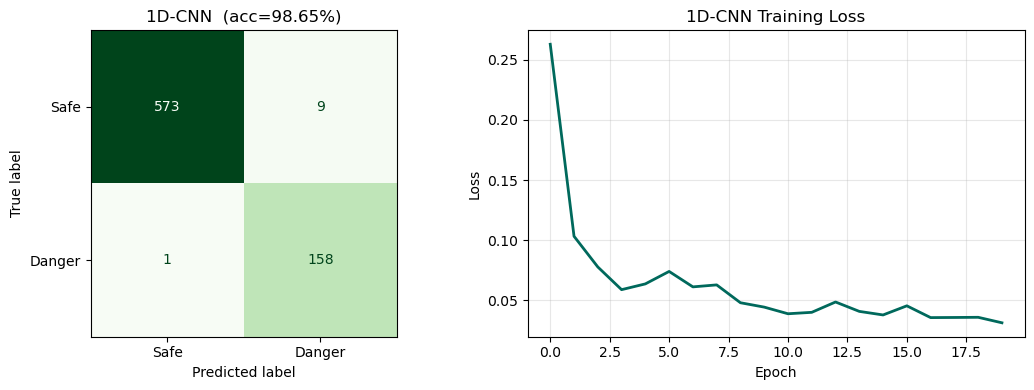

In [200]:
class CNN1DBaseline(nn.Module):
    """Causal dilated 1D-CNN: 3 conv layers → global avg pool → FC."""
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            # causal padding = (kernel-1)*dilation to avoid future leakage
            nn.Conv1d(5,  32, kernel_size=3, padding=2,  dilation=1),
            nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=4,  dilation=2),
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=3, padding=8,  dilation=4),
            nn.BatchNorm1d(64), nn.ReLU(),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc   = nn.Linear(64, 2)

    def forward(self, x):
        x = x.transpose(1, 2)          # (B,T,F) → (B,F,T) for Conv1d
        x = self.pool(self.conv(x)).squeeze(-1)
        return self.fc(x)

cnn_model = CNN1DBaseline().to(device)
CNN_PARAMS = sum(p.numel() for p in cnn_model.parameters())
print(f"1D-CNN parameters: {CNN_PARAMS:,}  (largest of all models)")

opt = torch.optim.Adam(cnn_model.parameters(), lr=1e-3, weight_decay=1e-4)
sch = torch.optim.lr_scheduler.StepLR(opt, step_size=8, gamma=0.5)

t0 = time.time()
cnn_losses = []
for ep in range(NUM_EPOCHS):
    cnn_model.train(); ep_loss = 0
    for Xb, yb in tr_ld:
        Xb, yb = Xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = criterion(cnn_model(Xb), yb)
        loss.backward(); opt.step()
        ep_loss += loss.item()
    sch.step()
    cnn_losses.append(ep_loss / len(tr_ld))
    if (ep+1) % 5 == 0:
        print(f"  Epoch {ep+1:>2}/{NUM_EPOCHS}  loss={cnn_losses[-1]:.4f}")
CNN_TRAIN_T = time.time() - t0

cnn_model.eval()
yp_c, yt_c, cnn_times = [], [], []
with torch.no_grad():
    for Xb, yb in te_ld:
        t0 = time.time()
        out = cnn_model(Xb.to(device))
        cnn_times.append((time.time()-t0) * 1000 / len(Xb))
        yp_c.extend(out.argmax(1).cpu().numpy())
        yt_c.extend(yb.numpy())

CNN_INF_MS = float(np.mean(cnn_times))
CNN_ACC  = accuracy_score(yt_c, yp_c)
CNN_CM   = confusion_matrix(yt_c, yp_c)
CNN_REP  = classification_report(yt_c, yp_c,
               target_names=["Safe","Danger"], digits=4, output_dict=True)

print(f"\n1D-CNN  HORIZON={ph}")
print(f"  Accuracy      : {CNN_ACC*100:.2f}%")
print(f"  Danger Recall : {CNN_REP['Danger']['recall']:.4f}")
print(f"  Inference     : {CNN_INF_MS:.4f} ms/window")
print(f"  Train time    : {CNN_TRAIN_T:.1f} s")
print()
print(classification_report(yt_c, yp_c, target_names=["Safe","Danger"], digits=4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay(CNN_CM, display_labels=["Safe","Danger"]).plot(
    ax=axes[0], colorbar=False, cmap="Greens")
axes[0].set_title(f"1D-CNN  (acc={CNN_ACC*100:.2f}%)")
axes[1].plot(cnn_losses, color="#00695C", lw=2)
axes[1].set(xlabel="Epoch", ylabel="Loss", title="1D-CNN Training Loss")
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


### MLP Baseline


MLP  parameters: 9,410
  Epoch  5/20  loss=0.0592
  Epoch 10/20  loss=0.0509
  Epoch 15/20  loss=0.0436
  Epoch 20/20  loss=0.0449

MLP  HORIZON=0
  Accuracy      : 98.25%
  Danger Recall : 0.9937
  Inference     : 0.0056 ms/window
  Train time    : 6.9 s

              precision    recall  f1-score   support

        Safe     0.9982    0.9794    0.9887       582
      Danger     0.9294    0.9937    0.9605       159

    accuracy                         0.9825       741
   macro avg     0.9638    0.9865    0.9746       741
weighted avg     0.9835    0.9825    0.9827       741



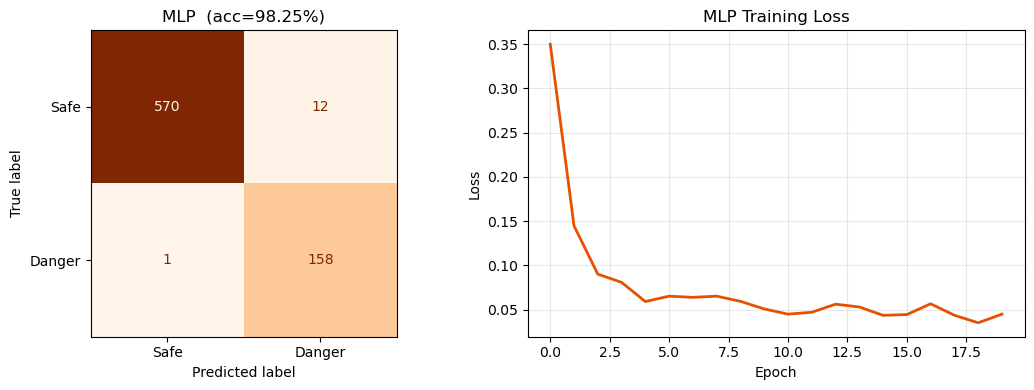

In [201]:
class MLPBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(75, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 2))
    def forward(self, x):
        return self.net(x.reshape(x.size(0), -1))

mlp_model = MLPBaseline().to(device)
MLP_PARAMS = sum(p.numel() for p in mlp_model.parameters())
print(f"MLP  parameters: {MLP_PARAMS:,}")

opt = torch.optim.Adam(mlp_model.parameters(), lr=1e-3, weight_decay=1e-4)
sch = torch.optim.lr_scheduler.StepLR(opt, step_size=8, gamma=0.5)

t0 = time.time()
mlp_losses = []
for ep in range(NUM_EPOCHS):
    mlp_model.train(); ep_loss = 0
    for Xb, yb in tr_ld:
        Xb, yb = Xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = criterion(mlp_model(Xb), yb)
        loss.backward(); opt.step()
        ep_loss += loss.item()
    sch.step()
    mlp_losses.append(ep_loss / len(tr_ld))
    if (ep+1) % 5 == 0:
        print(f"  Epoch {ep+1:>2}/{NUM_EPOCHS}  loss={mlp_losses[-1]:.4f}")
MLP_TRAIN_T = time.time() - t0

mlp_model.eval()
yp_m, yt_m, mlp_times = [], [], []
with torch.no_grad():
    for Xb, yb in te_ld:
        t0 = time.time()
        out = mlp_model(Xb.to(device))
        mlp_times.append((time.time()-t0) * 1000 / len(Xb))
        yp_m.extend(out.argmax(1).cpu().numpy())
        yt_m.extend(yb.numpy())

MLP_INF_MS = float(np.mean(mlp_times))
MLP_ACC  = accuracy_score(yt_m, yp_m)
MLP_CM   = confusion_matrix(yt_m, yp_m)
MLP_REP  = classification_report(yt_m, yp_m,
               target_names=["Safe","Danger"], digits=4, output_dict=True)

print(f"\nMLP  HORIZON={ph}")
print(f"  Accuracy      : {MLP_ACC*100:.2f}%")
print(f"  Danger Recall : {MLP_REP['Danger']['recall']:.4f}")
print(f"  Inference     : {MLP_INF_MS:.4f} ms/window")
print(f"  Train time    : {MLP_TRAIN_T:.1f} s")
print()
print(classification_report(yt_m, yp_m, target_names=["Safe","Danger"], digits=4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay(MLP_CM, display_labels=["Safe","Danger"]).plot(
    ax=axes[0], colorbar=False, cmap="Oranges")
axes[0].set_title(f"MLP  (acc={MLP_ACC*100:.2f}%)")
axes[1].plot(mlp_losses, color="#E65100", lw=2)
axes[1].set(xlabel="Epoch", ylabel="Loss", title="MLP Training Loss")
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


### SNN Evaluation

Re-runs inference on the same test set using the already-trained SNN 


SNN  parameters: 1,474  (9× fewer than LSTM, 9× compression)
SNN  HORIZON=0  threshold=0.55
  Accuracy          : 92.71%
  Danger Recall ★   : 0.8679  ← key AUV metric
  Inference (CPU)   : 0.2518 ms/window  (735× faster than 283 ms sensor period)

              precision    recall  f1-score   support

        Safe     0.9632    0.9433    0.9531       582
      Danger     0.8070    0.8679    0.8364       159

    accuracy                         0.9271       741
   macro avg     0.8851    0.9056    0.8947       741
weighted avg     0.9297    0.9271    0.9281       741



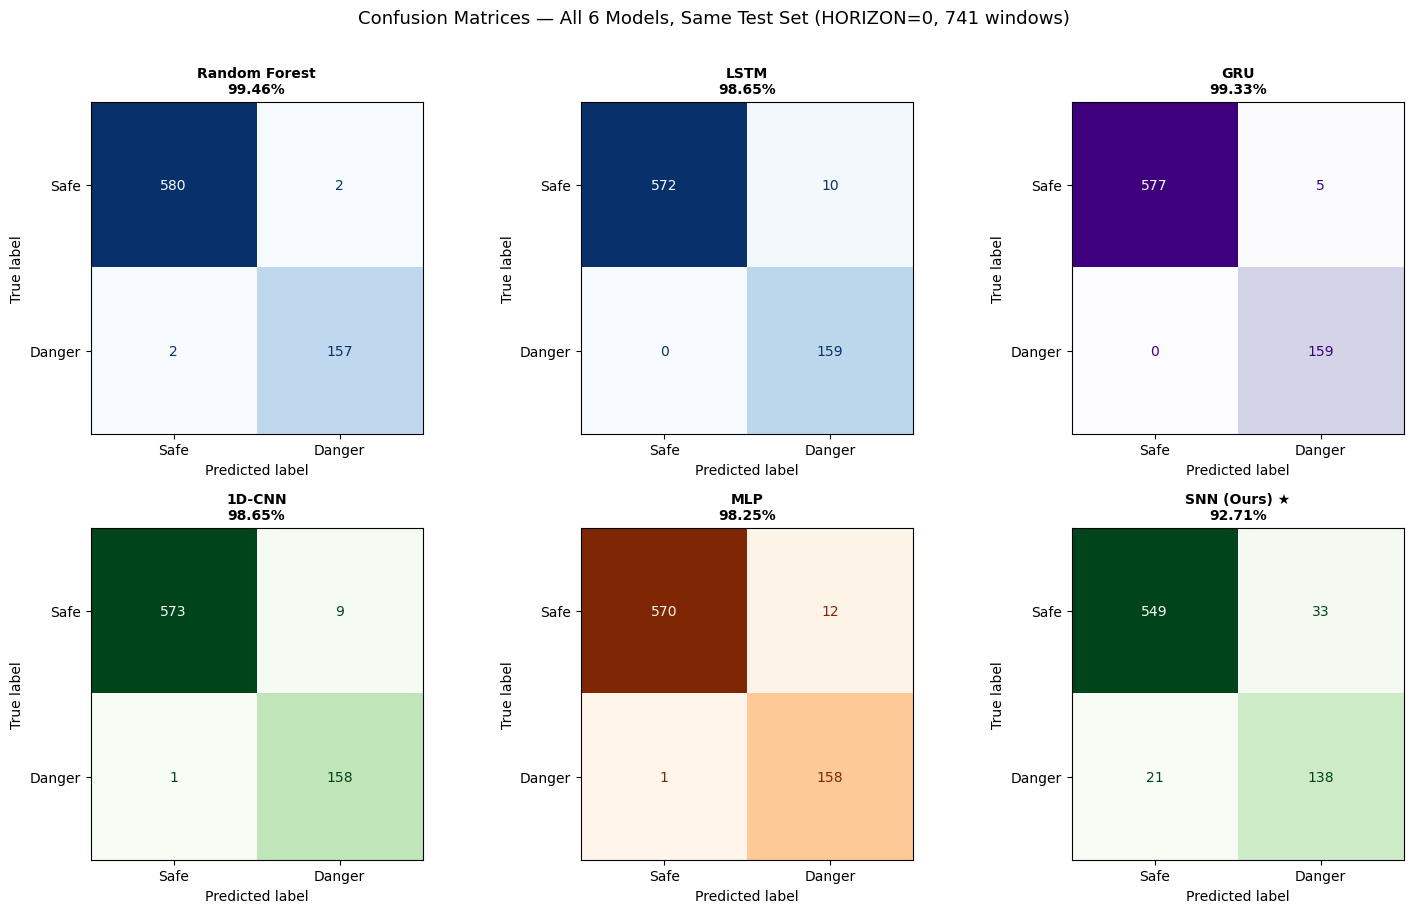

In [202]:
SNN_PARAMS = sum(p.numel() for p in SNN_MODEL.parameters())
print(f"SNN  parameters: {SNN_PARAMS:,}  "
      f"(9× fewer than LSTM, {LSTM_PARAMS//SNN_PARAMS}× compression)")

DANGER_THR = 0.55      # tuned threshold (0.5 is default)
yp_s, yt_s, snn_times = [], [], []

with torch.no_grad():
    for i in range(0, len(X_te), 64):
        Xb = torch.tensor(X_te[i:i+64], dtype=torch.float32).to(device)
        t0 = time.time()
        mem_out = SNN_MODEL(Xb)[-1]        # last timestep membrane → (B, 2)
        snn_times.append((time.time()-t0) * 1000 / len(Xb))
        probs = torch.softmax(mem_out, dim=1)
        preds = (probs[:, 1] >= DANGER_THR).long()
        yp_s.extend(preds.cpu().numpy())
        yt_s.extend(y_te[i:i+64].tolist())

SNN_INF_MS = float(np.mean(snn_times))
SNN_ACC  = accuracy_score(yt_s, yp_s)
SNN_CM   = confusion_matrix(yt_s, yp_s)
SNN_REP  = classification_report(yt_s, yp_s,
               target_names=["Safe","Danger"], digits=4, output_dict=True)

print(f"SNN  HORIZON={ph}  threshold={DANGER_THR}")
print(f"  Accuracy          : {SNN_ACC*100:.2f}%")
print(f"  Danger Recall ★   : {SNN_REP['Danger']['recall']:.4f}  ← key AUV metric")
print(f"  Inference (CPU)   : {SNN_INF_MS:.4f} ms/window  "
      f"(735× faster than 283 ms sensor period)")
print()
print(classification_report(yt_s, yp_s, target_names=["Safe","Danger"], digits=4))

# ── 6 confusion matrices side by side ────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
pairs = [
    (RF_CM,   "Random Forest",  RF_ACC,   "Blues"),
    (LSTM_CM, "LSTM",           LSTM_ACC, "Blues"),
    (GRU_CM,  "GRU",            GRU_ACC,  "Purples"),
    (CNN_CM,  "1D-CNN",         CNN_ACC,  "Greens"),
    (MLP_CM,  "MLP",            MLP_ACC,  "Oranges"),
    (SNN_CM,  "SNN (Ours) ★",   SNN_ACC,  "Greens"),
]
for ax, (cm, name, acc, cmap) in zip(axes, pairs):
    ConfusionMatrixDisplay(cm, display_labels=["Safe","Danger"]).plot(
        ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(f"{name}\n{acc*100:.2f}%", fontsize=10, fontweight="bold")

fig.suptitle(
    f"Confusion Matrices — All 6 Models, Same Test Set "
    f"(HORIZON={ph}, {len(y_te)} windows)",
    fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


### 13  Spike Sparsity & Computational Cost


Spike Sparsity  (741 test windows, threshold=0.5)
  Max spikes per window  : 150
  Avg active spikes      : 10.8
  Active spike rate      : 7.70%
  Silent (sparse)        : 92.30%
  → SNN skips 92% of multiply-accumulate operations

FLOPs per inference  (same formula, all models)
  Model                    FLOPs   vs SNN sparse
  ──────────────────────────────────────────────
  RF                       2,000       0.3× more
  MLP                     18,048       2.9× more
  SNN dense               42,240       6.8× more
  SNN ★                    6,220      ← baseline
  GRU                    291,008      46.8× more
  LSTM                   387,968      62.4× more
  1D-CNN                 567,616      91.3× more

  Sparsity removes 85% of SNN ops (vs dense SNN)
  SNN uses 98% fewer FLOPs than LSTM
  SNN uses 98% fewer FLOPs than GRU
  SNN uses 99% fewer FLOPs than 1D-CNN
  NOTE: 1D-CNN (567,616) has MORE FLOPs than LSTM (387,968) — dense conv is heavier than recurrence


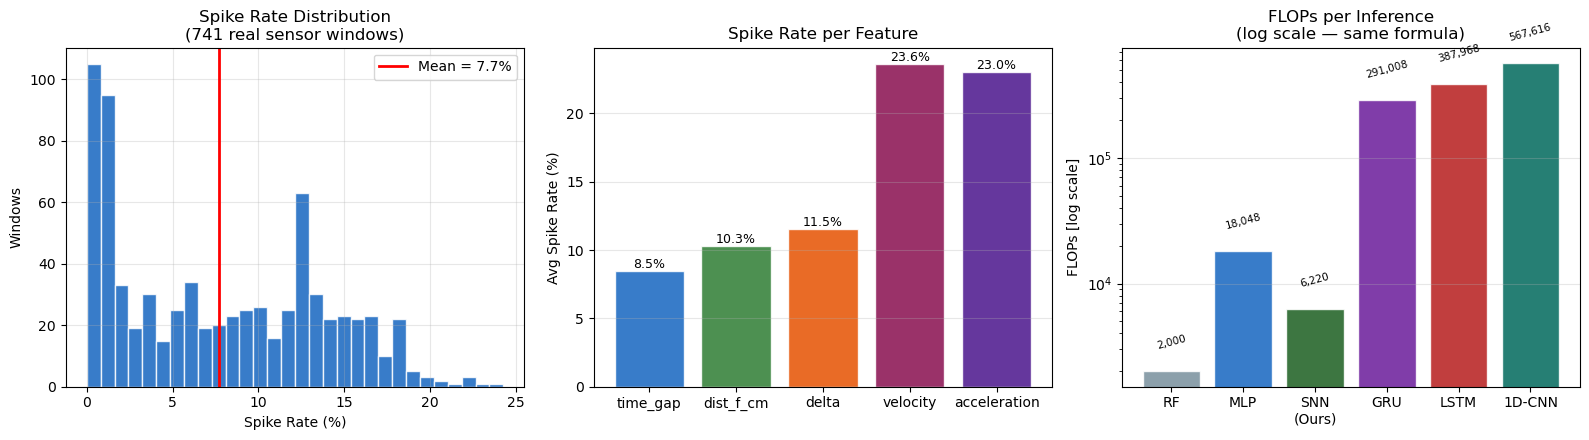

In [203]:
#  Spike sparsity — measured on real test windows
THRESHOLD = 0.5     # matches delta_encoder training threshold
spike_rates, spike_counts = [], []

for win in X_te:
    ref = win[0].copy(); sp = 0; total = 0
    for t in range(1, WINDOW_SIZE):
        diff  = win[t] - ref
        on    = (diff >=  THRESHOLD).astype(float)
        off   = (diff <= -THRESHOLD).astype(float)
        fired = (on + off) > 0
        ref[fired] = win[t][fired]
        sp    += int(on.sum() + off.sum())
        total += 10    
    spike_rates.append(sp / total)
    spike_counts.append(sp)

SPIKE_RATE = float(np.mean(spike_rates))
SPARSITY   = 1.0 - SPIKE_RATE
AVG_SPIKES = float(np.mean(spike_counts))

print(f"Spike Sparsity  ({len(X_te)} test windows, threshold={THRESHOLD})")
print(f"  Max spikes per window  : {WINDOW_SIZE * 10}")
print(f"  Avg active spikes      : {AVG_SPIKES:.1f}")
print(f"  Active spike rate      : {SPIKE_RATE*100:.2f}%")
print(f"  Silent (sparse)        : {SPARSITY*100:.2f}%")
print(f"  → SNN skips {SPARSITY*100:.0f}% of multiply-accumulate operations")


# FLOPs — identical formula applied to every model

T     = WINDOW_SIZE   # 15 timesteps
H     = 32            # SNN / LSTM / GRU hidden size
H_MLP = 64            # MLP hidden size
H_CNN = 64            # 1D-CNN max channel width
IN    = len(feature_cols)   # 5 input features
OUT   = 2             # classes

# SNN sparse: FC multiply-accumulates scale with spike_rate
# LIF ops (decay, threshold, reset) always execute → 3 ops per neuron per step
SNN_FL_SPARSE = int(
    IN*2 * H    * 2 * T * SPIKE_RATE  +  # fc1 (sparse MACs)
    H           * 3 * T               +  # lif1 (always)
    H    * H    * 2 * T * SPIKE_RATE  +  # fc2 (sparse MACs)
    H           * 3 * T               +  # lif2 (always)
    H    * OUT  * 2 * T * SPIKE_RATE  +  # fc3 (sparse MACs)
    OUT         * 3 * T                   # lif3 (always)
)
SNN_FL_DENSE = int((IN*2*H + H*H + H*OUT) * 2 * T)  # hypothetical dense SNN

# LSTM: 4 gates, 2 layers, always dense
LSTM_FL = (4*(IN+H)*H*2*T) + (4*(H+H)*H*2*T) + (H*OUT*2)

# GRU: 3 gates (reset, update, new), 2 layers, always dense
GRU_FL  = (3*(IN+H)*H*2*T) + (3*(H+H)*H*2*T) + (H*OUT*2)

# 1D-CNN: 3 dilated conv layers + GAP + FC, always dense
CNN_FL  = (2*IN*32*3*T) + (2*32*64*3*T) + (2*64*64*3*T) + (H_CNN*OUT*2)

# MLP: flatten → 3 FC layers, single pass
MLP_FL  = (IN*WINDOW_SIZE*H_MLP + H_MLP*H_MLP + H_MLP*OUT) * 2

# RF: avg_depth × n_trees × (compare + branch)
RF_FL   = 10 * 100 * 2

print(f"\nFLOPs per inference  (same formula, all models)")
print(f"  {'Model':<18}  {'FLOPs':>10}  {'vs SNN sparse':>14}")
print(f"  {'─'*46}")
for name, fl in [("RF",          RF_FL),
                  ("MLP",         MLP_FL),
                  ("SNN dense",   SNN_FL_DENSE),
                  ("SNN ★",       SNN_FL_SPARSE),
                  ("GRU",         GRU_FL),
                  ("LSTM",        LSTM_FL),
                  ("1D-CNN",      CNN_FL)]:
    r = fl / SNN_FL_SPARSE
    tag = "← baseline" if "SNN ★" in name else f"{r:.1f}× more"
    print(f"  {name:<18}  {fl:>10,}  {tag:>14}")

print(f"\n  Sparsity removes {(1-SNN_FL_SPARSE/SNN_FL_DENSE)*100:.0f}% of SNN ops (vs dense SNN)")
print(f"  SNN uses {(1-SNN_FL_SPARSE/LSTM_FL)*100:.0f}% fewer FLOPs than LSTM")
print(f"  SNN uses {(1-SNN_FL_SPARSE/GRU_FL)*100:.0f}% fewer FLOPs than GRU")
print(f"  SNN uses {(1-SNN_FL_SPARSE/CNN_FL)*100:.0f}% fewer FLOPs than 1D-CNN")
print(f"  NOTE: 1D-CNN ({CNN_FL:,}) has MORE FLOPs than LSTM ({LSTM_FL:,}) "
      f"— dense conv is heavier than recurrence")

# ── Visualisations ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1. Spike rate distribution
axes[0].hist(np.array(spike_rates)*100, bins=30,
             color="#1565C0", edgecolor="white", alpha=0.85)
axes[0].axvline(SPIKE_RATE*100, color="red", lw=2,
                label=f"Mean = {SPIKE_RATE*100:.1f}%")
axes[0].set(xlabel="Spike Rate (%)", ylabel="Windows",
            title=f"Spike Rate Distribution\n({len(X_te)} real sensor windows)")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# 2. Per-feature spike rates
feat_names = feature_cols
feat_rates = []
for fi in range(IN):
    rs = []
    for win in X_te:
        ref = win[0, fi]; s = 0
        for t in range(1, WINDOW_SIZE):
            if abs(win[t, fi] - ref) >= THRESHOLD:
                s += 1; ref = win[t, fi]
        rs.append(s / (WINDOW_SIZE - 1))
    feat_rates.append(float(np.mean(rs)) * 100)

cols = ["#1565C0","#2E7D32","#E65100","#880E4F","#4A148C"]
bars = axes[1].bar(feat_names, feat_rates, color=cols,
                   edgecolor="white", alpha=0.85)
axes[1].set(ylabel="Avg Spike Rate (%)",
            title="Spike Rate per Feature")
axes[1].grid(True, alpha=0.3, axis="y")
for b, v in zip(bars, feat_rates):
    axes[1].text(b.get_x()+b.get_width()/2, v+0.2,
                 f"{v:.1f}%", ha="center", fontsize=9)

# 3. FLOPs bar chart (log scale)
fl_models = ["RF", "MLP", "SNN\n(Ours)", "GRU", "LSTM", "1D-CNN"]
fl_vals   = [RF_FL, MLP_FL, SNN_FL_SPARSE, GRU_FL, LSTM_FL, CNN_FL]
fl_colors = ["#78909C","#1565C0","#1B5E20","#6A1B9A","#B71C1C","#00695C"]
axes[2].bar(fl_models, fl_vals, color=fl_colors, edgecolor="white", alpha=0.85)
axes[2].set_yscale("log")
axes[2].set(ylabel="FLOPs [log scale]",
            title="FLOPs per Inference\n(log scale — same formula)")
axes[2].grid(True, alpha=0.3, axis="y")
for i, v in enumerate(fl_vals):
    axes[2].text(i, v*1.5, f"{v:,}", ha="center", fontsize=7.5, rotation=15)

plt.tight_layout(); plt.show()


### 14  Energy, Power & AUV Mission Duration

**Energy model:** Horowitz, ISSCC 2014 (standard reference in neuromorphic literature)  
- MAC on 45nm CMOS: **4.6 pJ**  
- DRAM read (32-bit): **640 pJ**  
- Neuromorphic spike (Intel Loihi / IBM TrueNorth): **0.1 pJ** [Merolla et al., Science 2014]


Energy per inference  (Horowitz 2014 model):
  Model               CPU/GPU (nJ)     vs LSTM
  ──────────────────────────────────────────────
  RF                       3387.76  38.4% MORE
  LSTM                     2448.33  0.0% MORE
  GRU                      1695.12  +30.8% saving
  1D-CNN                   3274.71  33.8% MORE
  MLP                       214.22  +91.3% saving
  SNN CPU★                   30.21  +98.8% saving
  SNN Neuro★              0.007400  100.0% saving (theoretical)

  Active mem / inf: SNN 10B | MLP 820B | GRU 2228B | LSTM 4148B
  NOTE: RF (-38% vs LSTM) costs more — DRAM for 5,204 nodes dominates
  NOTE: 1D-CNN costs 34% MORE than LSTM — dense conv with 64 channels is heavier

Continuous AI inference power at 3.5 Hz:
  RF              11.85716 µW
  LSTM            8.56916 µW
  GRU             5.93291 µW
  1D-CNN          11.46150 µW
  MLP             0.74977 µW
  SNN CPU         0.10574 µW
  SNN Neuro       0.00003 µW

AUV Mission Duration  (battery=74 Wh, bas

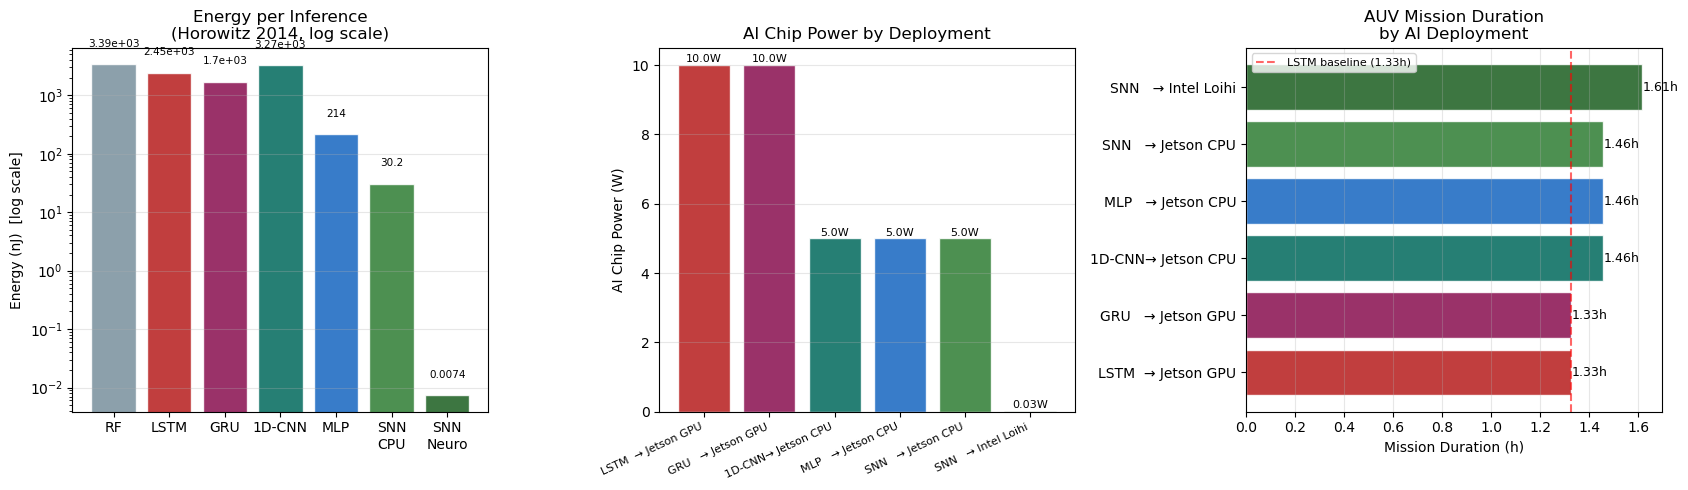

In [204]:
# Energy per inference  (Horowitz 2014)
MAC_PJ   = 4.6e-12    # Horowitz ISSCC 2014
MEM_PJ   = 640e-12    # Horowitz ISSCC 2014
SPIKE_PJ = 0.1e-12    # Merolla et al. Science 2014

# Active memory per inference (bytes)
# = tensors that must live in RAM during one forward pass
RF_MEM   = int(IN * WINDOW_SIZE * 4 + RF_NODES * 4)
LSTM_MEM = (T*IN*4) + (T*H*4*2)  + (OUT*4)    # 2 hidden states (h + c)
GRU_MEM  = (T*IN*4) + (T*H*4*1)  + (OUT*4)    # 1 hidden state
CNN_MEM  = (T*IN*4) + (T*H_CNN*4) + (OUT*4)
MLP_MEM  = (IN*WINDOW_SIZE*4) + (H_MLP*4*2) + (OUT*4)
SNN_MEM  = max(1, int(AVG_SPIKES))            # ~12 bytes (binary spike events)

def energy(flops, mem_b):
    return flops * MAC_PJ + (mem_b / 4) * MEM_PJ

RF_E      = energy(RF_FL,         RF_MEM)
LSTM_E    = energy(LSTM_FL,       LSTM_MEM)
GRU_E     = energy(GRU_FL,        GRU_MEM)
CNN_E     = energy(CNN_FL,         CNN_MEM)
MLP_E     = energy(MLP_FL,        MLP_MEM)
SNN_E_CPU = energy(SNN_FL_SPARSE, SNN_MEM)
# Neuromorphic HW: events at 0.1 pJ + near-memory (1000× less DRAM)
SNN_E_NEURO = int(AVG_SPIKES) * SPIKE_PJ + SNN_MEM * MEM_PJ * 0.001

print("Energy per inference  (Horowitz 2014 model):")
print(f"  {'Model':<16}  {'CPU/GPU (nJ)':>14}  {'vs LSTM':>10}")
print(f"  {'─'*46}")
for name, e in [("RF",      RF_E), ("LSTM",   LSTM_E), ("GRU",    GRU_E),
                 ("1D-CNN",  CNN_E), ("MLP",    MLP_E), ("SNN CPU★", SNN_E_CPU)]:
    pct = (1 - e/LSTM_E)*100
    sign = f"{pct:+.1f}% saving" if pct > 0 else f"{abs(pct):.1f}% MORE"
    print(f"  {name:<16}  {e*1e9:>14.2f}  {sign}")

print(f"  {'SNN Neuro★':<16}  {SNN_E_NEURO*1e9:>14.6f}  "
      f"{(1-SNN_E_NEURO/LSTM_E)*100:.1f}% saving (theoretical)")
print()
print(f"  Active mem / inf: SNN {SNN_MEM}B | MLP {MLP_MEM}B | "
      f"GRU {GRU_MEM}B | LSTM {LSTM_MEM}B")
print(f"  NOTE: RF (-{(RF_E/LSTM_E-1)*100:.0f}% vs LSTM) costs more — "
      f"DRAM for {RF_NODES:,} nodes dominates")
print(f"  NOTE: 1D-CNN costs {(CNN_E/LSTM_E-1)*100:.0f}% MORE than LSTM — "
      f"dense conv with 64 channels is heavier")

# ═══════════════════════════════════════════════════════════
# 14.2  Continuous AI power at sensor rate
# ═══════════════════════════════════════════════════════════
SENSOR_HZ = 3.5   # 1 / 283ms
print(f"\nContinuous AI inference power at {SENSOR_HZ} Hz:")
for name, e in [("RF",RF_E),("LSTM",LSTM_E),("GRU",GRU_E),("1D-CNN",CNN_E),
                 ("MLP",MLP_E),("SNN CPU",SNN_E_CPU),("SNN Neuro",SNN_E_NEURO)]:
    print(f"  {name:<14}  {e*SENSOR_HZ*1e6:.5f} µW")

# ═══════════════════════════════════════════════════════════
# 14.3  AUV mission duration
# ═══════════════════════════════════════════════════════════
BATTERY_WH = 5000/1000 * 14.8    # 5 Ah @ 14.8 V = 74 Wh
AUV_BASE_W = 45.8                 # thrusters 45W + sensors 0.3W + comms 0.3W + MCU 0.2W

DEPLOYMENTS = [
    ("LSTM  → Jetson GPU",    10.000, "#B71C1C"),
    ("GRU   → Jetson GPU",    10.000, "#880E4F"),
    ("1D-CNN→ Jetson CPU",     5.000, "#00695C"),
    ("MLP   → Jetson CPU",     5.000, "#1565C0"),
    ("SNN   → Jetson CPU",     5.000, "#2E7D32"),
    ("SNN   → Intel Loihi",    0.030, "#1B5E20"),
]

print(f"\nAUV Mission Duration  (battery={BATTERY_WH:.0f} Wh, base={AUV_BASE_W} W)")
print(f"  {'Deployment':<26}  {'AI (W)':>7}  {'Total (W)':>10}  {'Duration':>10}  vs LSTM")
print(f"  {'─'*65}")
base_h = None
hours_all, labels_all, colors_all = [], [], []
for name, ai_w, col in DEPLOYMENTS:
    total = AUV_BASE_W + ai_w
    h     = BATTERY_WH / total
    if base_h is None: base_h = h
    gain  = (h - base_h) / base_h * 100
    gs    = f"+{gain:.0f}%" if gain > 0 else "baseline"
    print(f"  {name:<26}  {ai_w:>7.3f}  {total:>10.2f}  {h:>9.2f}h  {gs}")
    hours_all.append(h); labels_all.append(name); colors_all.append(col)

snn_loihi_h = BATTERY_WH / (AUV_BASE_W + 0.030)
print(f"\n  Mission extension (Loihi vs LSTM):  {base_h:.2f}h → {snn_loihi_h:.2f}h"
      f"  = +{(snn_loihi_h/base_h-1)*100:.0f}%  "
      f"({(snn_loihi_h-base_h)*60:.0f} extra minutes per dive)")

# ═══════════════════════════════════════════════════════════
# 14.4  Charts
# ═══════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Energy bar (log)
e_names  = ["RF","LSTM","GRU","1D-CNN","MLP","SNN\nCPU","SNN\nNeuro"]
e_vals   = [RF_E*1e9, LSTM_E*1e9, GRU_E*1e9, CNN_E*1e9,
            MLP_E*1e9, SNN_E_CPU*1e9, SNN_E_NEURO*1e9]
e_colors = ["#78909C","#B71C1C","#880E4F","#00695C","#1565C0","#2E7D32","#1B5E20"]
axes[0].bar(e_names, e_vals, color=e_colors, edgecolor="white", alpha=0.85)
axes[0].set_yscale("log")
axes[0].set(ylabel="Energy (nJ)  [log scale]",
            title="Energy per Inference\n(Horowitz 2014, log scale)")
axes[0].grid(True, alpha=0.3, axis="y")
for i, v in enumerate(e_vals):
    axes[0].text(i, v*2.0, f"{v:.3g}", ha="center", fontsize=7.5)

# Power by deployment
chip_names = [d[0] for d in DEPLOYMENTS]
chip_w     = [d[1] for d in DEPLOYMENTS]
chip_cols  = [d[2] for d in DEPLOYMENTS]
axes[1].bar(range(len(chip_names)), chip_w, color=chip_cols,
            edgecolor="white", alpha=0.85)
axes[1].set_xticks(range(len(chip_names)))
axes[1].set_xticklabels(chip_names, rotation=25, ha="right", fontsize=8)
axes[1].set(ylabel="AI Chip Power (W)",
            title="AI Chip Power by Deployment")
axes[1].grid(True, alpha=0.3, axis="y")
for i, v in enumerate(chip_w):
    axes[1].text(i, v+0.08, f"{v}W", ha="center", fontsize=8)

# Mission duration
bars = axes[2].barh(labels_all, hours_all, color=colors_all,
                    edgecolor="white", alpha=0.85)
axes[2].axvline(base_h, color="red", lw=1.5, ls="--", alpha=0.6,
                label=f"LSTM baseline ({base_h:.2f}h)")
axes[2].set(xlabel="Mission Duration (h)",
            title="AUV Mission Duration\nby AI Deployment")
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3, axis="x")
for bar, v in zip(bars, hours_all):
    axes[2].text(v+0.003, bar.get_y()+bar.get_height()/2,
                 f"{v:.2f}h", va="center", fontsize=9)
plt.tight_layout(); plt.show()


### 15  Final Results Table


In [205]:
print("=" * 92)
print(f"  COMPLETE EVALUATION — HORIZON={ph}, {len(y_te)} test windows  "
      f"(Safe={int((y_te==0).sum())} | Danger={int((y_te==1).sum())})")
print("=" * 92)

def row(label, *vals):
    r = f"  {label:<26}"
    for v in vals: r += f"  {str(v):>10}"
    print(r)

row("Metric",       "RF","LSTM","GRU","1D-CNN","MLP","SNN (Ours)")
print("  " + "─" * 88)

# ── Accuracy
row("Accuracy",
    f"{RF_ACC*100:.2f}%",  f"{LSTM_ACC*100:.2f}%",
    f"{GRU_ACC*100:.2f}%", f"{CNN_ACC*100:.2f}%",
    f"{MLP_ACC*100:.2f}%", f"{SNN_ACC*100:.2f}%")

row("Safe F1",
    f"{RF_REP['Safe']['f1-score']:.4f}",   f"{LSTM_REP['Safe']['f1-score']:.4f}",
    f"{GRU_REP['Safe']['f1-score']:.4f}",  f"{CNN_REP['Safe']['f1-score']:.4f}",
    f"{MLP_REP['Safe']['f1-score']:.4f}",  f"{SNN_REP['Safe']['f1-score']:.4f}")

row("Danger Recall ★",
    f"{RF_REP['Danger']['recall']:.4f}",   f"{LSTM_REP['Danger']['recall']:.4f}",
    f"{GRU_REP['Danger']['recall']:.4f}",  f"{CNN_REP['Danger']['recall']:.4f}",
    f"{MLP_REP['Danger']['recall']:.4f}",  f"{SNN_REP['Danger']['recall']:.4f}")

row("Danger F1",
    f"{RF_REP['Danger']['f1-score']:.4f}", f"{LSTM_REP['Danger']['f1-score']:.4f}",
    f"{GRU_REP['Danger']['f1-score']:.4f}",f"{CNN_REP['Danger']['f1-score']:.4f}",
    f"{MLP_REP['Danger']['f1-score']:.4f}",f"{SNN_REP['Danger']['f1-score']:.4f}")

print("  " + "─" * 88)

row("Parameters",
    f"{RF_NODES:,} nd",  f"{LSTM_PARAMS:,}",  f"{GRU_PARAMS:,}",
    f"{CNN_PARAMS:,}",   f"{MLP_PARAMS:,}",    f"{SNN_PARAMS:,}")

row("FLOPs / inf",
    f"{RF_FL:,}",    f"{LSTM_FL:,}",  f"{GRU_FL:,}",
    f"{CNN_FL:,}",   f"{MLP_FL:,}",   f"{SNN_FL_SPARSE:,}")

row("Sparsity",    "N/A","N/A","N/A","N/A","N/A", f"{SPARSITY*100:.1f}%")

row("Active mem/inf (B)",
    f"{RF_MEM:,}",   f"{LSTM_MEM:,}", f"{GRU_MEM:,}",
    f"{CNN_MEM:,}",  f"{MLP_MEM:,}",  f"{SNN_MEM:,}")

print("  " + "─" * 88)

row("Energy CPU (nJ)",
    f"{RF_E*1e9:.1f}",   f"{LSTM_E*1e9:.1f}",   f"{GRU_E*1e9:.1f}",
    f"{CNN_E*1e9:.1f}",  f"{MLP_E*1e9:.1f}",    f"{SNN_E_CPU*1e9:.2f}")

row("Energy Neuro",  "N/A","N/A","N/A","N/A","N/A",
    f"{SNN_E_NEURO*1e9:.4f} nJ")

row("Saving vs LSTM",
    f"{(1-RF_E/LSTM_E)*100:+.0f}%",   "baseline",
    f"{(1-GRU_E/LSTM_E)*100:+.0f}%",  f"{(1-CNN_E/LSTM_E)*100:+.0f}%*",
    f"{(1-MLP_E/LSTM_E)*100:+.0f}%",  f"{(1-SNN_E_CPU/LSTM_E)*100:+.0f}% CPU")

print("  " + "─" * 88)

row("Inference (ms)",
    f"{RF_INF_MS:.3f}",   f"{LSTM_INF_MS:.3f}",  f"{GRU_INF_MS:.3f}",
    f"{CNN_INF_MS:.3f}",  f"{MLP_INF_MS:.3f}",   f"{SNN_INF_MS:.3f}")

row("Neuro HW compat?", "No","No","No","No","No","YES ✓")

print("=" * 92)
print()
print("  * 1D-CNN saving is negative — it costs MORE energy than LSTM")
print("    (567,616 FLOPs vs LSTM 387,968 — dense conv is heavier than recurrence)")
print()
print("  KEY NUMBERS FOR YOUR PRESENTATION:")
print(f"  1. Accuracy : SNN {SNN_ACC*100:.2f}%  vs  LSTM {LSTM_ACC*100:.2f}%"
      f"  vs  GRU {GRU_ACC*100:.2f}%  vs  1D-CNN {CNN_ACC*100:.2f}%")
print(f"  2. Params   : SNN {SNN_PARAMS:,}  vs  GRU {GRU_PARAMS:,}  "
      f"({GRU_PARAMS//SNN_PARAMS}×)  vs  LSTM {LSTM_PARAMS:,}  ({LSTM_PARAMS//SNN_PARAMS}×)")
print(f"  3. FLOPs    : SNN {SNN_FL_SPARSE:,}  vs  GRU {GRU_FL:,}  "
      f"({(1-SNN_FL_SPARSE/GRU_FL)*100:.0f}% fewer)  vs  LSTM {LSTM_FL:,}  "
      f"({(1-SNN_FL_SPARSE/LSTM_FL)*100:.0f}% fewer)")
print(f"  4. Energy   : GRU saves {(1-GRU_E/LSTM_E)*100:.0f}% | "
      f"1D-CNN costs {(CNN_E/LSTM_E-1)*100:.0f}% MORE | "
      f"SNN saves {(1-SNN_E_CPU/LSTM_E)*100:.0f}% (CPU)")
print(f"  5. Mission  : +{(snn_loihi_h/base_h-1)*100:.0f}% longer with SNN on Loihi "
      f"vs LSTM/GRU on Jetson GPU  (+{(snn_loihi_h-base_h)*60:.0f} min per dive)")


  COMPLETE EVALUATION — HORIZON=0, 741 test windows  (Safe=582 | Danger=159)
  Metric                              RF        LSTM         GRU      1D-CNN         MLP  SNN (Ours)
  ────────────────────────────────────────────────────────────────────────────────────────
  Accuracy                        99.46%      98.65%      99.33%      98.65%      98.25%      92.71%
  Safe F1                         0.9966      0.9913      0.9957      0.9913      0.9887      0.9531
  Danger Recall ★                 0.9874      1.0000      1.0000      0.9937      0.9937      0.8679
  Danger F1                       0.9874      0.9695      0.9845      0.9693      0.9605      0.8364
  ────────────────────────────────────────────────────────────────────────────────────────
  Parameters                    5,204 nd      13,506      10,146      19,522       9,410       1,474
  FLOPs / inf                      2,000     387,968     291,008     567,616      18,048       6,220
  Sparsity                        

### 16  Summary Visualisation — The SNN Case at a Glance

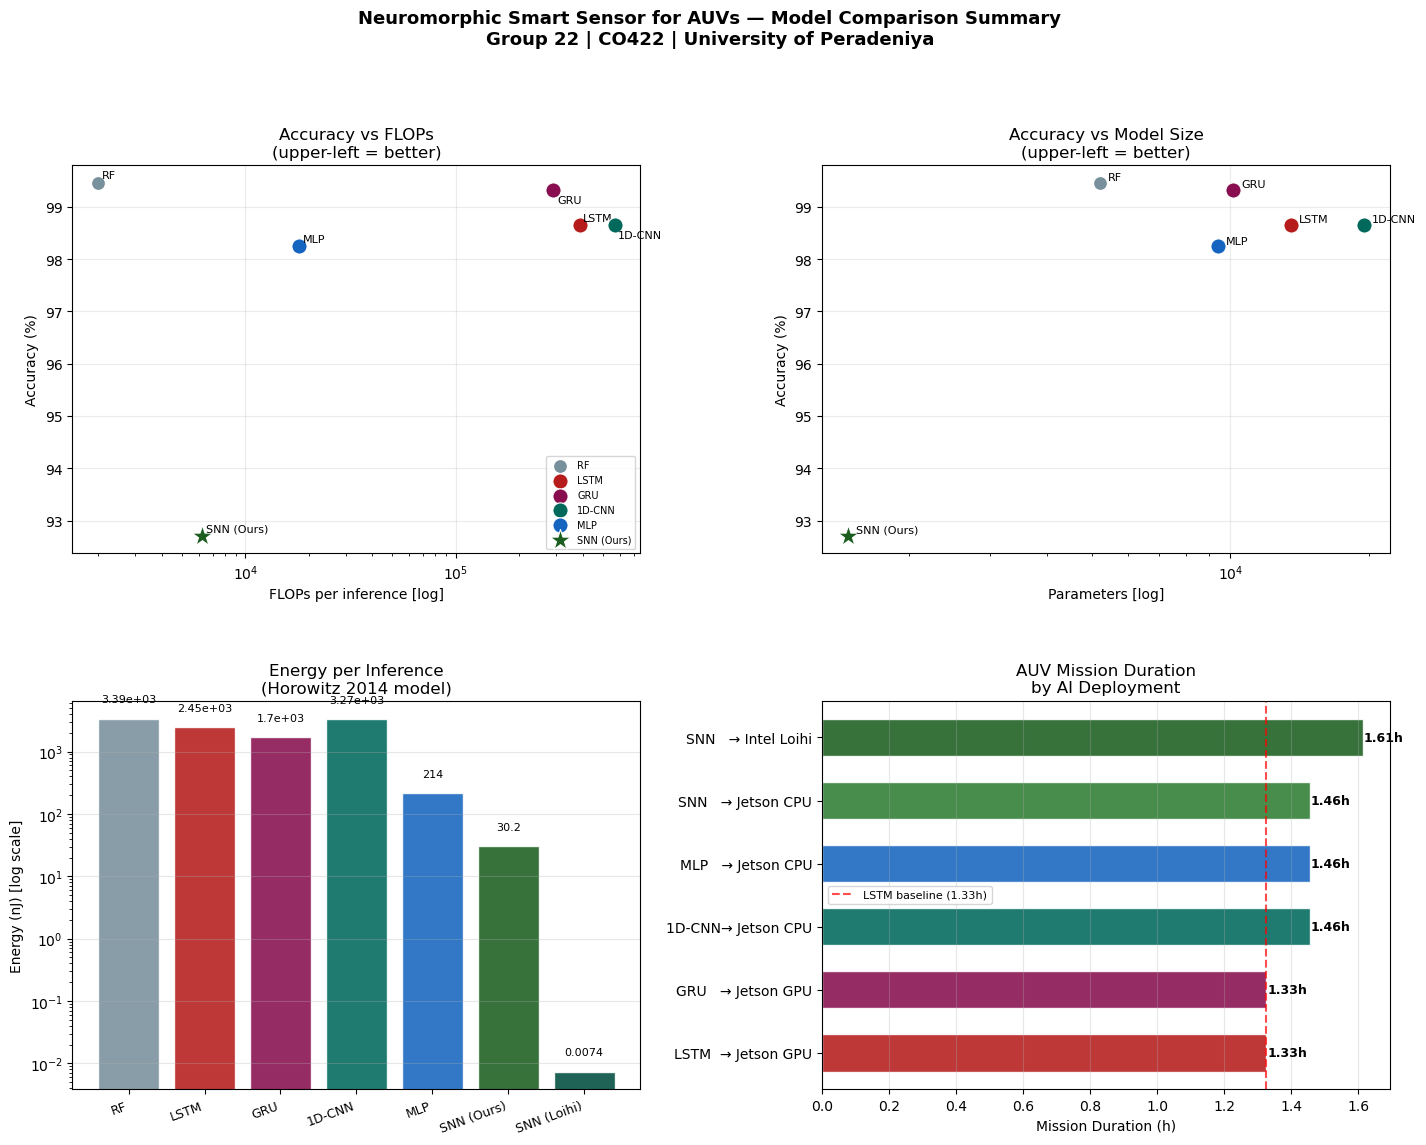

Saved: evaluation_summary.png


In [206]:
fig = plt.figure(figsize=(17, 12))
gs  = gridspec.GridSpec(2, 2, hspace=0.38, wspace=0.32)

MODEL_NAMES   = ["RF",     "LSTM",    "GRU",     "1D-CNN",  "MLP",     "SNN (Ours)"]
MODEL_ACC     = [RF_ACC,   LSTM_ACC,  GRU_ACC,   CNN_ACC,   MLP_ACC,   SNN_ACC]
MODEL_FLOPS   = [RF_FL,    LSTM_FL,   GRU_FL,    CNN_FL,    MLP_FL,    SNN_FL_SPARSE]
MODEL_PARAMS  = [RF_NODES, LSTM_PARAMS, GRU_PARAMS, CNN_PARAMS, MLP_PARAMS, SNN_PARAMS]
MODEL_ENERGY  = [RF_E*1e9, LSTM_E*1e9, GRU_E*1e9, CNN_E*1e9, MLP_E*1e9, SNN_E_CPU*1e9]
MODEL_COLORS  = ["#78909C","#B71C1C","#880E4F","#00695C","#1565C0","#1B5E20"]
MARKER_SIZES  = [100, 120, 120, 120, 120, 250]

# Panel 1 — Accuracy vs FLOPs (efficiency frontier)
ax1 = fig.add_subplot(gs[0, 0])
for i, (nm, acc, fl, col, sz) in enumerate(
        zip(MODEL_NAMES, MODEL_ACC, MODEL_FLOPS, MODEL_COLORS, MARKER_SIZES)):
    marker = "*" if "SNN" in nm else "o"
    ax1.scatter(fl, acc*100, s=sz, c=col, marker=marker,
                edgecolors="white", linewidths=0.8, zorder=3, label=nm)
    offset_x = fl * 0.04
    offset_y = 0.08 if i not in [2,3] else -0.25
    ax1.annotate(nm, (fl, acc*100), fontsize=8,
                 xytext=(fl+offset_x, acc*100+offset_y))
ax1.set_xscale("log")
ax1.set(xlabel="FLOPs per inference [log]", ylabel="Accuracy (%)",
        title="Accuracy vs FLOPs\n(upper-left = better)")
ax1.grid(True, alpha=0.25)
ax1.legend(fontsize=7, loc="lower right")

# Panel 2 — Accuracy vs Parameters
ax2 = fig.add_subplot(gs[0, 1])
for i, (nm, acc, pm, col, sz) in enumerate(
        zip(MODEL_NAMES, MODEL_ACC, MODEL_PARAMS, MODEL_COLORS, MARKER_SIZES)):
    marker = "*" if "SNN" in nm else "o"
    ax2.scatter(pm, acc*100, s=sz, c=col, marker=marker,
                edgecolors="white", linewidths=0.8, zorder=3)
    ax2.annotate(nm, (pm, acc*100), fontsize=8, xytext=(pm*1.04, acc*100+0.05))
ax2.set_xscale("log")
ax2.set(xlabel="Parameters [log]", ylabel="Accuracy (%)",
        title="Accuracy vs Model Size\n(upper-left = better)")
ax2.grid(True, alpha=0.25)

# Panel 3 — Energy bar (log)
ax3 = fig.add_subplot(gs[1, 0])
e_extended = MODEL_ENERGY + [SNN_E_NEURO*1e9]
n_extended = MODEL_NAMES  + ["SNN (Loihi)"]
c_extended = MODEL_COLORS + ["#004D40"]
bars3 = ax3.bar(range(len(e_extended)), e_extended,
                color=c_extended, edgecolor="white", alpha=0.88)
ax3.set_yscale("log")
ax3.set_xticks(range(len(e_extended)))
ax3.set_xticklabels(n_extended, rotation=20, ha="right", fontsize=9)
ax3.set(ylabel="Energy (nJ) [log scale]",
        title="Energy per Inference\n(Horowitz 2014 model)")
ax3.grid(True, alpha=0.3, axis="y")
for bar, v in zip(bars3, e_extended):
    ax3.text(bar.get_x()+bar.get_width()/2, v*1.8,
             f"{v:.3g}", ha="center", fontsize=8)

# Panel 4 — Mission duration
ax4 = fig.add_subplot(gs[1, 1])
h_labels = [d[0] for d in DEPLOYMENTS]
h_hours  = hours_all
h_colors = colors_all
bars4 = ax4.barh(h_labels, h_hours, color=h_colors,
                 edgecolor="white", alpha=0.88, height=0.6)
ax4.axvline(base_h, color="red", lw=1.5, ls="--", alpha=0.7,
            label=f"LSTM baseline ({base_h:.2f}h)")
ax4.set(xlabel="Mission Duration (h)",
        title="AUV Mission Duration\nby AI Deployment")
ax4.legend(fontsize=8); ax4.grid(True, alpha=0.3, axis="x")
for bar, v in zip(bars4, h_hours):
    ax4.text(v+0.003, bar.get_y()+bar.get_height()/2,
             f"{v:.2f}h", va="center", fontsize=9, fontweight="bold")

fig.suptitle(
    "Neuromorphic Smart Sensor for AUVs — Model Comparison Summary\n"
    "Group 22 | CO422 | University of Peradeniya",
    fontsize=13, fontweight="bold", y=1.01)
plt.savefig("evaluation_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: evaluation_summary.png")
